# Multi-Sensor Data Fusion for Multi-Target Drone Tracking in Counter-UAS Applications

This code refers to Umberto Maffei's Master Degree Thesis project.
It is an implementation of Multi-Sensor Data Fusion in order to track drones in C-UAS applications.
There will be three sensors:

1. Radar: a radar sensor that return info about the target in terms of azimuth, elevation and range.
2. RF-DOA: a Radio Frequency Direction of Arrival sensor that return the bearing of a detected target.
3. Acoustic: ???

This project is based on [StoneSoup Framework](https://stonesoup.readthedocs.io/en/latest/index.html).

**Architettura dual-tracker:**
- **Radar Tracker**: riceve esclusivamente le detection del radar (CartesianToElevationBearingRange)
- **RF-DOA Tracker**: riceve le detection triangolate dai 3 sensori RF-DOA (Two-Stage Pipeline)
- I due percorsi di tracking sono completamente separati e producono plot distinti


## Imports


In [1]:
## Imports

from copy import deepcopy
from datetime import datetime, timedelta
import numpy as np
import random
import math
from itertools import tee, combinations
from collections import defaultdict
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

## Stone Soup imports

from stonesoup.types.detection import TrueDetection, Clutter, Detection
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity, RandomWalk, KnownTurnRate)
from stonesoup.models.transition.base import CombinedGaussianTransitionModel
from stonesoup.models.transition.graph import OptimalPathToDestinationTransitionModel
from stonesoup.models.transition.nonlinear import ConstantTurn
from stonesoup.models.measurement.nonlinear import (CartesianToElevationBearingRange, Cartesian2DToBearing, CartesianToBearingRange)
from stonesoup.types.graph import RoadNetwork
from stonesoup.simulator.simple import SingleTargetGroundTruthSimulator
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.sensor.sensor import SimpleSensor
from stonesoup.base import Property
from stonesoup.models.clutter import ClutterModel
from stonesoup.platform.base import FixedPlatform
from stonesoup.simulator.simple import (MultiTargetGroundTruthSimulator, SwitchMultiTargetGroundTruthSimulator)
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.plotter import Plotter, Dimension
from stonesoup.models.base import ReversibleModel
from stonesoup.tracker.simple import MultiTargetMixtureTracker
from stonesoup.initiator.base import Initiator
from stonesoup.feeder.multi import MultiDataFeeder
from stonesoup.predictor.kalman import UnscentedKalmanPredictor
from stonesoup.updater.kalman import UnscentedKalmanUpdater
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDA
from stonesoup.dataassociator.neighbour import NearestNeighbour
from stonesoup.deleter.time import UpdateTimeStepsDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator


# --- Scipy Monkey Patch for Robust Covariance Handling ---
import scipy.stats
old_logpdf = scipy.stats.multivariate_normal.logpdf

def robust_logpdf(x, mean=None, cov=1, allow_singular=False):
    try:
        return old_logpdf(x, mean=mean, cov=cov, allow_singular=allow_singular)
    except Exception:
        return old_logpdf(x, mean=mean, cov=cov, allow_singular=True)

scipy.stats.multivariate_normal.logpdf = robust_logpdf


## Ground truth simulation parameters


In [2]:
## Ground Truth Simulation params

start_time = datetime.now()
np.random.seed(16)
random.seed(45)

initial_number_targets = 1 # initial number of target
birth_rate = 0         # new target spawn probability at each timestamp
death_probability = 0  # death probability at each timestamp
num_steps = 300        # simulated steps


## Sensor parameters

The next cell contains the values related to the sensor accuracy.
For the radar, are defined three standard deviations for each output parameter.
Since the RF-DOA sensor produce only information about bearing, only one standard deviation is defined.


In [3]:
## Tuning the sensors accuracy params (+/-)

radar_ele_nois_std_dev = 3 # radar elevation nois std dev 
radar_azi_nois_std_dev = 0.8 # radar azimuth nois std dev
radar_ran_nois_std_dev = 3 # radar range nois std dev
radar_max_range = 4000     # rfdoa max range

rfdoa_azi_nois_std_dev = 1.5 # rfdoa azimuth nois std dev
rfdoa_max_range = 4500     # rfdoa max range

# Soglia di deduplicazione spaziale post-triangolazione.
TRIANG_DEDUP_DIST = 300  # [m]


## Clutter models for false position detections

The class ClutterModel define a clutter model based on the select params:
+ the clutter rate (number of clutter detection at each timestamp)
+ probability distribution
+ required parameters for the defined distribution

In this case two clutter models are defined, for each sensor. In partricular for the RF-DOA sensor the clutter is defined only along two coordinates because it refers to the Cartesian2DToBearing measurement model.


In [4]:
## Clutter models

radar_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
    (  8_000, 10_000),   # z [m]
)

# This time the clutter distribution is defined only along x and y because
# the measurement model used for model the rfdoa is Cartesian2DToBearing

rfdoa_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
)

radar_clutter_model = ClutterModel(
    clutter_rate = 0.2,
    distribution = np.random.default_rng().uniform,
    dist_params = radar_clutter_params
)

rfdoa_clutter_model = ClutterModel(
    clutter_rate = 0.2,
    distribution = np.random.default_rng().uniform,
    dist_params = rfdoa_clutter_params
)


## Sensor #1: elevation, bearing and range radar

This type of sensor class, given real trajectory points, return info regarding elevation, bearing and range of this point for each timestamp.
It uses the CartesianToElevationBearingRange model that assume a 3D cartesian space.


In [5]:
## Radar sensor: bearing, elevation and range

# The sensor noise covariance matrix. This is utilised by (and follows in format) 
# the underlying CartesianToElevationBearingRange model

noise_covar = CovarianceMatrix(np.diag([np.deg2rad(radar_ele_nois_std_dev)**2,np.deg2rad(radar_azi_nois_std_dev)**2, radar_ran_nois_std_dev**2]))

radar = RadarElevationBearingRange(
    ndim_state = 6,
    position_mapping = (0, 2, 4),   # [x,vx,y,vy,z,vz]
    noise_covar = noise_covar,
    clutter_model = radar_clutter_model,
    max_range = radar_max_range
)


## Sensor #2: Radio Frequency Direction of Arrival sensor

This type of sensor class, given real trajectory points, return info regarding the elevation only.
For defining this sensor the class SimpleSensor has been used.


In [6]:
### RF-DOA sensor: bearing only

# Cartesian2DToBearing maps 1-D measurement
# noise_covar 1x1

rf_noise_covar = np.array([[np.deg2rad(rfdoa_azi_nois_std_dev)**2]])  # 1x1 covariance


## New subclass RFDOASensor: it inherits methods and attributes from the StoneSoup SimpleSensor
# that is very useful to build a personalized sensor.

class RFDOASensor(SimpleSensor):

    # measurement_model: Cartesian2DToBearing = Property(doc="The Sensor's measurement model")
    max_range: float = Property(default=np.inf, doc="Max range")
    
    @property
    def measurement_model(self):
        return self._meas_model

    def is_detectable(self, state, measurement_model=None):
        meas_model = measurement_model or self.measurement_model
        target_pos = state.state_vector[list(meas_model.mapping), 0]  # shape (2,)
        if self.position is not None:
            sensor_pos = np.array([self.position[0, 0], self.position[1, 0]])
        else:
            sensor_pos = meas_model.translation_offset[:, 0]
        distance = np.linalg.norm(target_pos - sensor_pos)
        return distance <= self.max_range

    def is_clutter_detectable(self, detection):
        return True

# Istance of the new RFDOASensor class

rfdoa_sensor_1 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_1._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_2 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_2._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_3 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_3._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_1._meas_model.translation_offset = StateVector([[700], [2300]])
rfdoa_sensor_2._meas_model.translation_offset = StateVector([[-2300], [-800]])
rfdoa_sensor_3._meas_model.translation_offset = StateVector([[1600], [-1500]])

# RF-DOA sensor metadata used by triangulation engine and plots
SENSOR_POSITIONS = [(700, 2300), (-2300, -800), (1600, -1500)]
SENSOR_COLORS    = ['steelblue', 'teal', 'mediumpurple']
SENSOR_LABELS    = ['RF-DOA 1 (700, 2300)', 'RF-DOA 2 (-2300, -8000)', 'RF-DOA 3 (1600, -1500)']


## Platform definition

The StoneSoup framework provides a set of Platform classes for carring a number of different sensors.
In this case two different platform are defined for carring the two different sensors:
1. Fixed Platform in (0 m,0 m, 0 m) for the radar sensor
2. Fixed Platform in (1500 m, 1000 m, 0 m) for the RF-DOA sensor

This is done in order to simulate a real implementation scenario where, because of constraint in term of deployment, the sensor are located in different position.


In [7]:
## Platforms: one fixed platform per sensor, collocated at origin (0,0,0).

# Platform state vectors

platform_state_radar = State(StateVector([[0],[0],[0]]), start_time)
platform_state_rfdoa_1 = State(StateVector([[700],[2300],[0]]), start_time)
platform_state_rfdoa_2 = State(StateVector([[-2300],[-800],[0]]), start_time)
platform_state_rfdoa_3 = State(StateVector([[1600],[-1500],[0]]), start_time)


# Istance of FixePlatform for radar

radar_platform = FixedPlatform(
    states = platform_state_radar,
    position_mapping = (0, 1, 2),
    sensors = [radar],
)


# Istance of FixePlatform for rfdoa

rfdoa_platform_1 = FixedPlatform(
    states = platform_state_rfdoa_1,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_1],
)

rfdoa_platform_2 = FixedPlatform(
    states = platform_state_rfdoa_2,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_2],
)

rfdoa_platform_3 = FixedPlatform(
    states = platform_state_rfdoa_3,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_3],
)


## True Trajectory simulator (Ground Truth)

This section defines the objects for the Ground Truth simulator.


In [8]:
## Ground truth simulator

# State layout: [x, vx, y, vy, z, vz]
# Targets start near (0, 0, 2000 m).

# Instance of CombinedLinearGaussianTransitionModel classe with the defined params

transition_model_spiral = CombinedGaussianTransitionModel([
    KnownTurnRate((0.6, 0.6), 0.1),
    ConstantVelocity(0.1),
])

transition_model_knwturnrt = CombinedGaussianTransitionModel([
    KnownTurnRate((4, 5), 6),
    RandomWalk(15),
])

transition_model_knwturnrt_sm = CombinedGaussianTransitionModel([
    KnownTurnRate((0.001, 0.001), 0.02),
    RandomWalk(15),
])

transition_model_cnstvel = CombinedGaussianTransitionModel([
    # ConstantTurn(linear_noise_coeffs = (0.01, 0.01), turn_noise_coeff = 0.0006),
    ConstantVelocity(2),
    ConstantVelocity(2),
    RandomWalk(0.15),
])


def make_random_initial_state(seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Valori nominali
    pos_nominal_x = 0
    pos_nominal_y = 1500
    pos_nominal_z = 500
    vel_nominal_xy = 0
    vel_nominal_z = 3
    # Perturbazioni (sigma della posizione e velocita)
    pos_std_x = 800 
    pos_std_y = 800
    pos_std_z = 300
    vel_std_xy = 5    
    vel_std_z = 1     
    state_vec = StateVector([
        [pos_nominal_x + np.random.normal(0, pos_std_x)],
        [vel_nominal_xy + np.random.normal(0, vel_std_xy)],
        [pos_nominal_y + np.random.normal(0, pos_std_x)],
        [vel_nominal_xy + np.random.normal(0, vel_std_xy)],
        [pos_nominal_z + np.random.normal(0, pos_std_z)],
        [vel_nominal_z  + np.random.normal(0, vel_std_z)],
    ])
    covar = CovarianceMatrix(np.diag([1000, 5, 1000, 2, 300, 2]))
    return GaussianState(state_vector=state_vec, covar=covar)


# istance of MultiTargetGroundTruthSimulator class for ground truth points generation at each timestamp

gt_simulator_spiral = SingleTargetGroundTruthSimulator(
    transition_model = transition_model_spiral,
    initial_state = make_random_initial_state(6),
    timestep = timedelta(seconds=1),
    number_steps = num_steps
)

model_probs = np.array([[0.8, 0.2],   # da modello 0: rimani su 0, passa a 1
                        [0.15, 0.85]])  # da modello 1: torna a 0, rimani su 1

gt_simulator_csntvel = MultiTargetGroundTruthSimulator(
    transition_model = transition_model_cnstvel,
    initial_state = make_random_initial_state(34),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)

gt_simulator_knwtr = MultiTargetGroundTruthSimulator(
    transition_model = transition_model_knwturnrt_sm,
    initial_state = make_random_initial_state(31),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)

gt_simulator_mixed = SwitchMultiTargetGroundTruthSimulator(
    transition_models = [transition_model_knwturnrt, transition_model_cnstvel],
    model_probs = model_probs,
    initial_state = make_random_initial_state(14213),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)


gt_simulator = MultiDataFeeder([gt_simulator_spiral, gt_simulator_mixed, gt_simulator_knwtr, gt_simulator_csntvel])
#gt_simulator = gt_simulator_mixed


## Detection simulators


In [9]:
## Detection simulators

# One PlatformDetectionSimulator istance per sensor
# gt_simulator is split into 4 independent streams: 1 radar + 3 rfdoa
# radar stream: one branch for plotting, one for radar tracker (no rfdoa)
# rfdoa streams: one branch each for plotting, one branch each for triangulation engine (rfdoa tracker)

gt_sims = tee(gt_simulator, 4) # split gt_simulator for the four detection 

radar_sim = PlatformDetectionSimulator(
    groundtruth = gt_sims[0],
    platforms =[radar_platform],
)

#radar_plotting, radar_detector = tee(radar_sim, 2)

rfdoa_sim_1 = PlatformDetectionSimulator(
    groundtruth = gt_sims[1],
    platforms =[rfdoa_platform_1],
)

rfdoa_sim_2 = PlatformDetectionSimulator(
    groundtruth = gt_sims[2],
    platforms =[rfdoa_platform_2],
)

rfdoa_sim_3 = PlatformDetectionSimulator(
    groundtruth = gt_sims[3],
    platforms =[rfdoa_platform_3],
)

# splitting the simulation for next steps
# radar: one for plotting, one for radar-only tracker
# rfdoa: one for plotting, one for triangulation engine (rfdoa tracker)

radar_plotting, radar_tracker_input = tee(radar_sim, 2)
rfdoa_plotting_1, rfdoa_for_triangulation_1 = tee(rfdoa_sim_1, 2)
rfdoa_plotting_2, rfdoa_for_triangulation_2 = tee(rfdoa_sim_2, 2)
rfdoa_plotting_3, rfdoa_for_triangulation_3 = tee(rfdoa_sim_3, 2)

print(rfdoa_sensor_1.measurement_model.translation_offset)
print(rfdoa_sensor_2.measurement_model.translation_offset)
print(rfdoa_sensor_3.measurement_model.translation_offset)


[[ 700]
 [2300]]
[[-2300]
 [ -800]]
[[ 1600]
 [-1500]]


In [10]:
## Collect detections and truths for plotting

radar_detections = set()
rfdoa_detections_1 = set()
rfdoa_detections_2 = set()
rfdoa_detections_3 = set()
truths           = set()

for (time, r_dets), (_, rf1_dets), (_, rf2_dets), (_, rf3_dets) in zip(radar_plotting, rfdoa_plotting_1, rfdoa_plotting_2, rfdoa_plotting_3):
    truths.update(gt_simulator.groundtruth_paths)
    radar_detections.update(r_dets)
    rfdoa_detections_1.update(rf1_dets)
    rfdoa_detections_2.update(rf2_dets)
    rfdoa_detections_3.update(rf3_dets)

# Separate true detections from clutter within each set

radar_true    = {d for d in radar_detections  if isinstance(d, TrueDetection)}
radar_clutter = {d for d in radar_detections  if isinstance(d, Clutter)}
rfdoa1_true    = {d for d in rfdoa_detections_1  if isinstance(d, TrueDetection)}
rfdoa1_clutter = {d for d in rfdoa_detections_1  if isinstance(d, Clutter)}
rfdoa2_true    = {d for d in rfdoa_detections_2  if isinstance(d, TrueDetection)}
rfdoa2_clutter = {d for d in rfdoa_detections_2  if isinstance(d, Clutter)}
rfdoa3_true    = {d for d in rfdoa_detections_3  if isinstance(d, TrueDetection)}
rfdoa3_clutter = {d for d in rfdoa_detections_3  if isinstance(d, Clutter)}


# info

print(f'Ground truth paths  : {len(truths)}')
print(f'Radar  true dets    : {len(radar_true)}')
print(f'Radar  clutter      : {len(radar_clutter)}')
print(f'RFDOA1  true dets    : {len(rfdoa1_true)}')
print(f'RFDOA1  clutter      : {len(rfdoa1_clutter)}')
print(f'RFDOA2  true dets    : {len(rfdoa2_true)}')
print(f'RFDOA2  clutter      : {len(rfdoa2_clutter)}')
print(f'RFDOA3  true dets    : {len(rfdoa3_true)}')
print(f'RFDOA3  clutter      : {len(rfdoa3_clutter)}')


Ground truth paths  : 4
Radar  true dets    : 1143
Radar  clutter      : 218
RFDOA1  true dets    : 1192
RFDOA1  clutter      : 249
RFDOA2  true dets    : 1067
RFDOA2  clutter      : 255
RFDOA3  true dets    : 1157
RFDOA3  clutter      : 252


Text(0, 0.5, 'Y [m]')

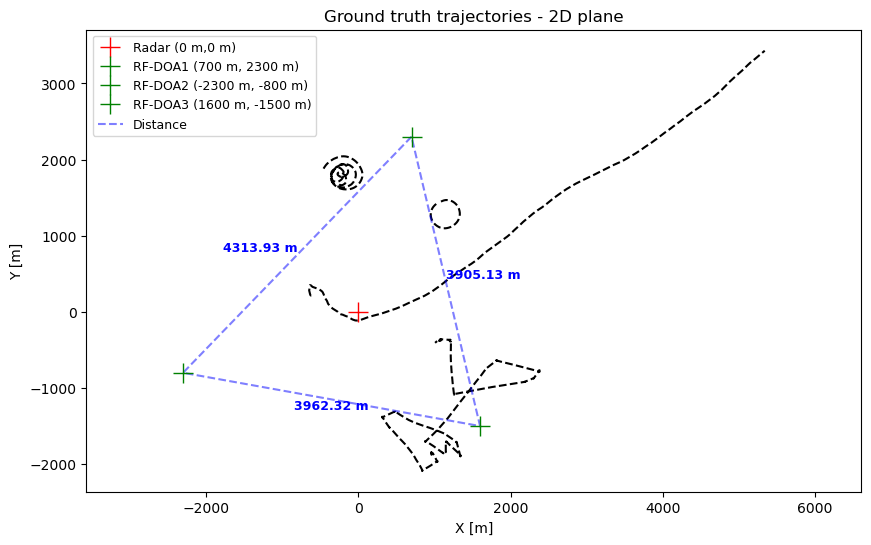

In [11]:
## 2D plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 2], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(700, 2300, 'g+', markersize=14, zorder=5, label='RF-DOA1 (700 m, 2300 m)')
plotter_gt.ax.plot(-2300, -800, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, -800 m)')
plotter_gt.ax.plot(1600, -1500, 'g+', markersize=14, zorder=5, label='RF-DOA3 (1600 m, -1500 m)')

# --- MODIFICA AGGIUNTA: Linee del triangolo ---
# Colleghiamo A-B, B-C, C-A (usiamo zorder=4 per metterle subito sotto i marker a croce)
x_coords = [700, -2300, 1600, 700]
y_coords = [2300, -800, -1500, 2300]
plotter_gt.ax.plot(x_coords, y_coords, color='blue', linestyle='--', alpha = 0.5, linewidth=1.5, zorder=4, label='Distance')

# --- MODIFICA AGGIUNTA: Testi delle distanze sui lati ---
# Distanza AB (posizionata nel punto medio tra A e B)
plotter_gt.ax.text((700 - 2300)/2, (2300 - 800)/2, '4313.93 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='right', va='bottom')

# Distanza BC (posizionata nel punto medio tra B e C)
plotter_gt.ax.text((-2300 + 1600)/2, (-800 - 1500)/2, '3962.32 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='center', va='top')

# Distanza AC (posizionata nel punto medio tra A e C)
plotter_gt.ax.text((700 + 1600)/2, (2300 - 1500)/2, '3905.13 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='left', va='bottom')
# ----------------------------------------------

plotter_gt.ax.set_title('Ground truth trajectories - 2D plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('X [m]')
plotter_gt.ax.set_ylabel('Y [m]')

Text(0, 0.5, 'Z [m]')

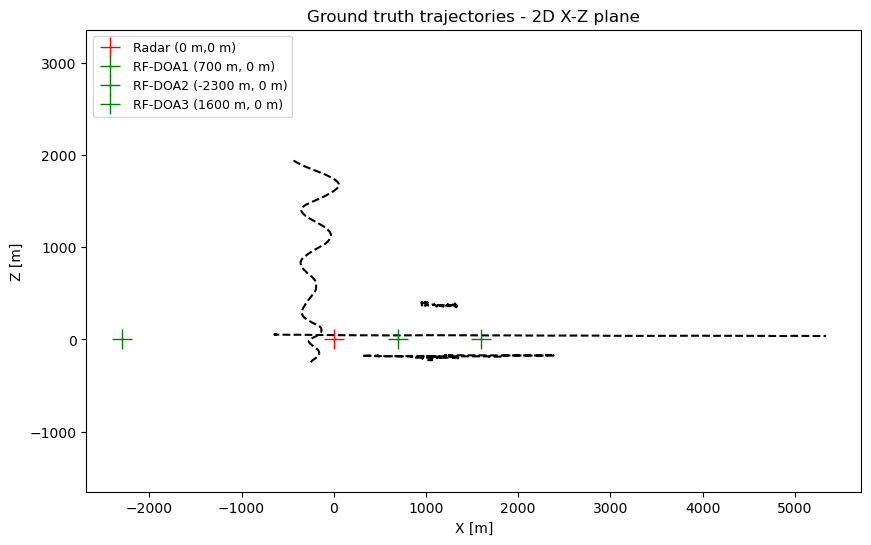

In [12]:
## 2D (X-Z plane) plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 4], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(700, 0, 'g+', markersize=14, zorder=5, label='RF-DOA1 (700 m, 0 m)')
plotter_gt.ax.plot(-2300, 0, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, 0 m)')
plotter_gt.ax.plot(1600, 0, 'g+', markersize=14, zorder=5, label='RF-DOA3 (1600 m, 0 m)')
plotter_gt.ax.set_title('Ground truth trajectories - 2D X-Z plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('X [m]')
plotter_gt.ax.set_ylabel('Z [m]')


Text(0, 0.5, 'Z [m]')

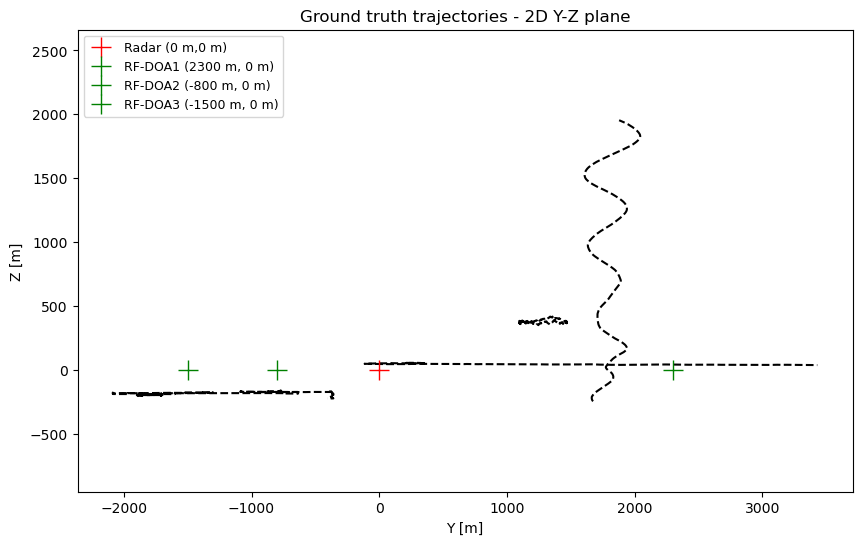

In [13]:
## 2D (Y-Z plane) plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [2, 4], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(2300, 0, 'g+', markersize=14, zorder=5, label='RF-DOA1 (2300 m, 0 m)')
plotter_gt.ax.plot(-800, 0, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-800 m, 0 m)')
plotter_gt.ax.plot(-1500, 0, 'g+', markersize=14, zorder=5, label='RF-DOA3 (-1500 m, 0 m)')
plotter_gt.ax.set_title('Ground truth trajectories - 2D Y-Z plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('Y [m]')
plotter_gt.ax.set_ylabel('Z [m]')


Text(0.5, 0, 'Z [m]')

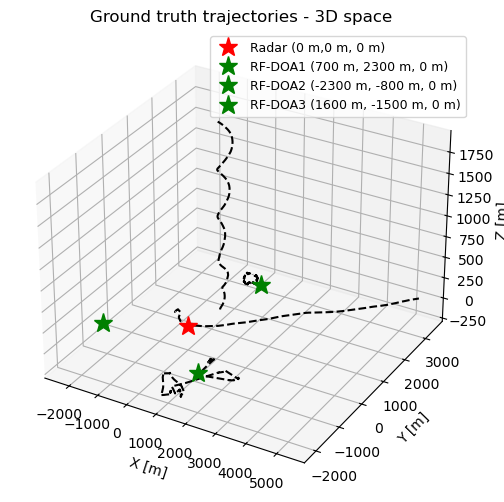

In [14]:
## 3D plot: Ground truth only + sensors position

plotter_gt_3d = Plotter(dimension=Dimension.THREE)
plotter_gt_3d.plot_ground_truths(truths, [0, 2, 4], color='black')
plotter_gt_3d.ax.plot(0,0,0, 'r*', markersize=14, zorder=5, label='Radar (0 m,0 m, 0 m)')
plotter_gt_3d.ax.plot(700, 2300, 0, 'g*', markersize=14, zorder=5, label='RF-DOA1 (700 m, 2300 m, 0 m)')
plotter_gt_3d.ax.plot(-2300, -800, 0, 'g*', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, -800 m, 0 m)')
plotter_gt_3d.ax.plot(1600, -1500, 0, 'g*', markersize=14, zorder=5, label='RF-DOA3 (1600 m, -1500 m, 0 m)')
plotter_gt_3d.ax.set_title('Ground truth trajectories - 3D space')
plotter_gt_3d.ax.legend(loc='upper right', fontsize=9)
plotter_gt_3d.ax.set_xlabel('X [m]')
plotter_gt_3d.ax.set_ylabel('Y [m]')
plotter_gt_3d.ax.set_zlabel('Z [m]')


Text(0.5, 1.0, 'Radar detections and ground truth - X-Y ground plane')

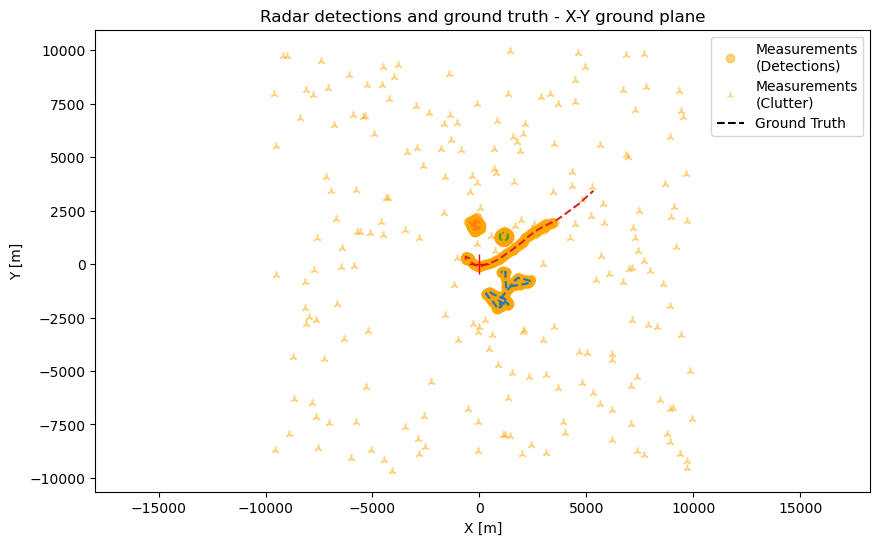

In [15]:
# Plot: 2D radar detections and GT

plotter = Plotter(Dimension.TWO)
plotter.plot_measurements(radar_detections, [0, 2], color='orange', marker='o', alpha=0.5)
plotter.plot_ground_truths(truths, [0, 2])
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')

# Platform marker
plotter.ax.plot(0, 0, 'r+', markersize=15, zorder=5, label='Radar (0 m, 0 m)')

# title
plotter.ax.set_title('Radar detections and ground truth - X-Y ground plane')


Text(0.5, 0.92, 'Radar detections and ground truth - 3D ground plane')

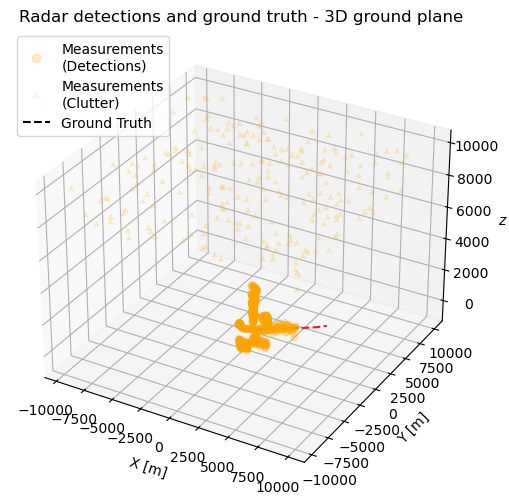

In [16]:
# Plot: 3D radar detections and GT
plotter = Plotter(Dimension.THREE)
plotter.plot_measurements(radar_detections, [0, 2,4], color='orange', marker='o', alpha=0.2)
plotter.plot_ground_truths(truths, [0, 2, 4], alpha=1)
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')
plotter.ax.set_title('Radar detections and ground truth - 3D ground plane')


Text(0, 0.5, 'Y [m]')

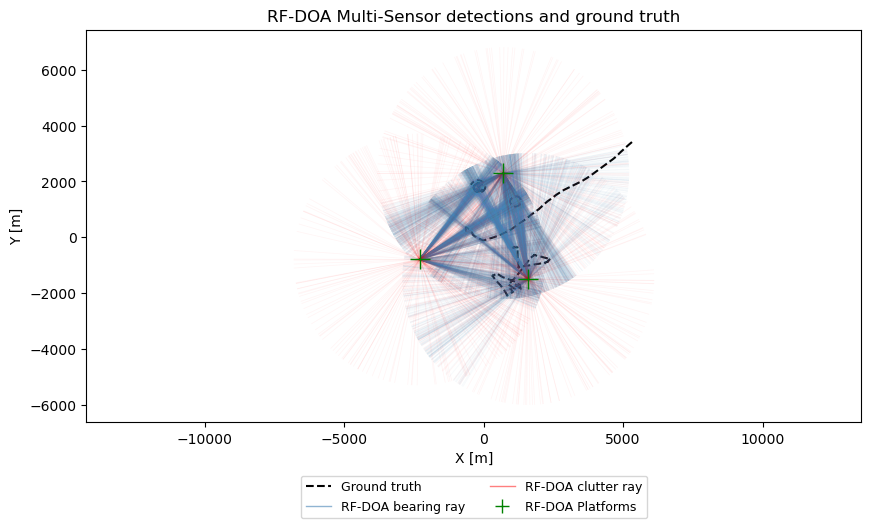

In [17]:
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')

# RF-DOA: draw bearing rays from origin
RAY_LEN = 4500   # arbitrary display length [m]

# Dizionario per mappare i sensori con le loro coordinate di origine e i loro set di rilevazioni
# Formato: (x_origin, y_origin): (true_detections, clutter_detections)
rfdoa_sensors_data = {
    (700, 2300):   (rfdoa1_true, rfdoa1_clutter),
    (-2300, -800):    (rfdoa2_true, rfdoa2_clutter),
    (1600, -1500):  (rfdoa3_true, rfdoa3_clutter)
}

# Plot dei raggi per tutti e 3 i sensori
for (x_orig, y_orig), (true_dets, clutter_dets) in rfdoa_sensors_data.items():

    # Plot true detections
    for det in true_dets:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x_orig, x_orig + RAY_LEN * np.cos(b)],
            [y_orig, y_orig + RAY_LEN * np.sin(b)],
            color='steelblue', alpha=0.04, linewidth=0.7
        )

    # Plot clutter detections
    for det in clutter_dets:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x_orig, x_orig + RAY_LEN * np.cos(b)],
            [y_orig, y_orig + RAY_LEN * np.sin(b)],
            color='red', alpha=0.04, linewidth=0.6
        )

    # Platform marker per ciascun sensore
    plotter.ax.plot(x_orig, y_orig, 'g+', markersize=14, zorder=5)


# Legend
legend_elems = [
    Line2D([0], [0], color='black',     linestyle='--', lw=1.5,           label='Ground truth'),
    Line2D([0], [0], color='steelblue', lw=1,           alpha=0.6,        label='RF-DOA bearing ray'),
    Line2D([0], [0], color='red',       lw=1,           alpha=0.5,        label='RF-DOA clutter ray'),
    Line2D([0], [0], color='green',     lw=0,           marker='+', ms=10, label='RF-DOA Platforms'),
]

# put legend below plot like reference notebook
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
plotter.ax.set_title('RF-DOA Multi-Sensor detections and ground truth')
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')


Text(0, 0.5, 'Y [m]')

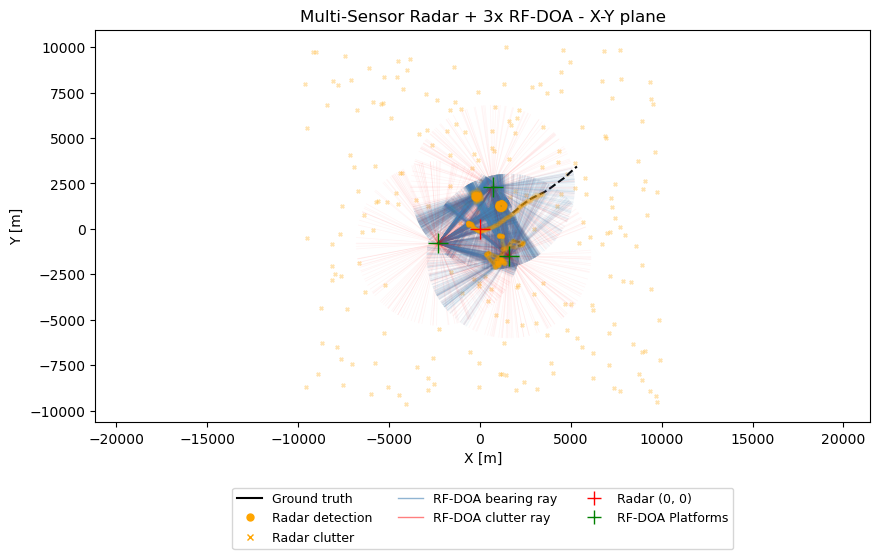

In [18]:
import numpy as np
from matplotlib.lines import Line2D

# Plot: Stone Soup Plotter (2-D, X-Y plane)

# Stone Soup plotter for ground truths
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')


# Radar detections: convert (el, bearing, range) to (x, y) and overlay
def spherical_to_xy(det):
    sv = det.state_vector
    el, az, r = float(sv[0]), float(sv[1]), float(sv[2])
    x = r * np.cos(el) * np.cos(az)
    y = r * np.cos(el) * np.sin(az)
    return x, y


if radar_true:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_true])
    plotter.ax.scatter(
        rxs, rys,
        s=6, c='orange', alpha=0.09, zorder=3, label='Radar detections',
    )

if radar_clutter:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_clutter])
    plotter.ax.scatter(
        cxs, cys,
        s=6, c='orange', marker='x', alpha=0.3, label='Radar clutter',
    )

# RF-DOA: Define platforms and their respective detection sets
# Format: (x_origin, y_origin): (true_detections, clutter_detections)
rfdoa_mapping = {
    (700, 2300): (rfdoa1_true, rfdoa1_clutter),
    (-2300, -800): (rfdoa2_true, rfdoa2_clutter),
    (1600, -1500): (rfdoa3_true, rfdoa3_clutter),
}

RAY_LEN = 4500  # arbitrary display length [m]

for (x0, y0), (true_set, clutter_set) in rfdoa_mapping.items():
    # Draw true bearing rays
    for det in true_set:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x0, x0 + RAY_LEN * np.cos(b)],
            [y0, y0 + RAY_LEN * np.sin(b)],
            color='steelblue', alpha=0.06, linewidth=0.7,
        )

    # Draw clutter bearing rays
    for det in clutter_set:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x0, x0 + RAY_LEN * np.cos(b)],
            [y0, y0 + RAY_LEN * np.sin(b)],
            color='red', alpha=0.04, linewidth=0.6,
        )

    # Add platform marker for this RF-DOA sensor
    plotter.ax.plot(x0, y0, 'g+', markersize=14, zorder=5)

# Radar platform marker
plotter.ax.plot(0, 0, 'r+', markersize=14, zorder=5)

# Legend
legend_elems = [
    Line2D([0], [0], color='black', lw=1.5, label='Ground truth'),
    Line2D([0], [0], color='orange', lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0], [0], color='orange', lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0], [0], color='steelblue', lw=1, alpha=0.6, label='RF-DOA bearing ray'),
    Line2D([0], [0], color='red', lw=1, alpha=0.5, label='RF-DOA clutter ray'),
    Line2D([0], [0], color='red', lw=0, marker='+', ms=10, label='Radar (0, 0)'),
    Line2D([0], [0], color='green', lw=0, marker='+', ms=10, label='RF-DOA Platforms'),
]

# Adjust layout to fit legend below
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(
    handles=legend_elems,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=9,
)

plotter.ax.set_title('Multi-Sensor Radar + 3x RF-DOA - X-Y plane')
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')


                       REPORT: ERRORS                       
RADAR - 3D RMSE: 102.609 m
RADAR - Max error -> X: 90.60m, Y: 239.15m, Z: 605.98m
------------------------------------------------------------
RADAR - Max Error -> Elevation: 9.586 deg, Azimuth: 2.752 deg, Range: 12.19m
RADAR - RMSE -> Elevation: 3.021 deg Azimuth: 0.792 deg Range: 3.102m
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
RF-DOA 1 - RMSE Bearing: 22.143 deg
RF-DOA 1 - Bearing error -> Max: 44.302 deg, Min: 0.010 deg
------------------------------
RF-DOA 2 - RMSE Bearing: 34.987 deg
RF-DOA 2 - Bearing error -> Max: 58.067 deg, Min: 14.184 deg
------------------------------
RF-DOA 3 - RMSE Bearing: 32.956 deg
RF-DOA 3 - Bearing error -> Max: 106.265 deg, Min: 0.482 deg
------------------------------


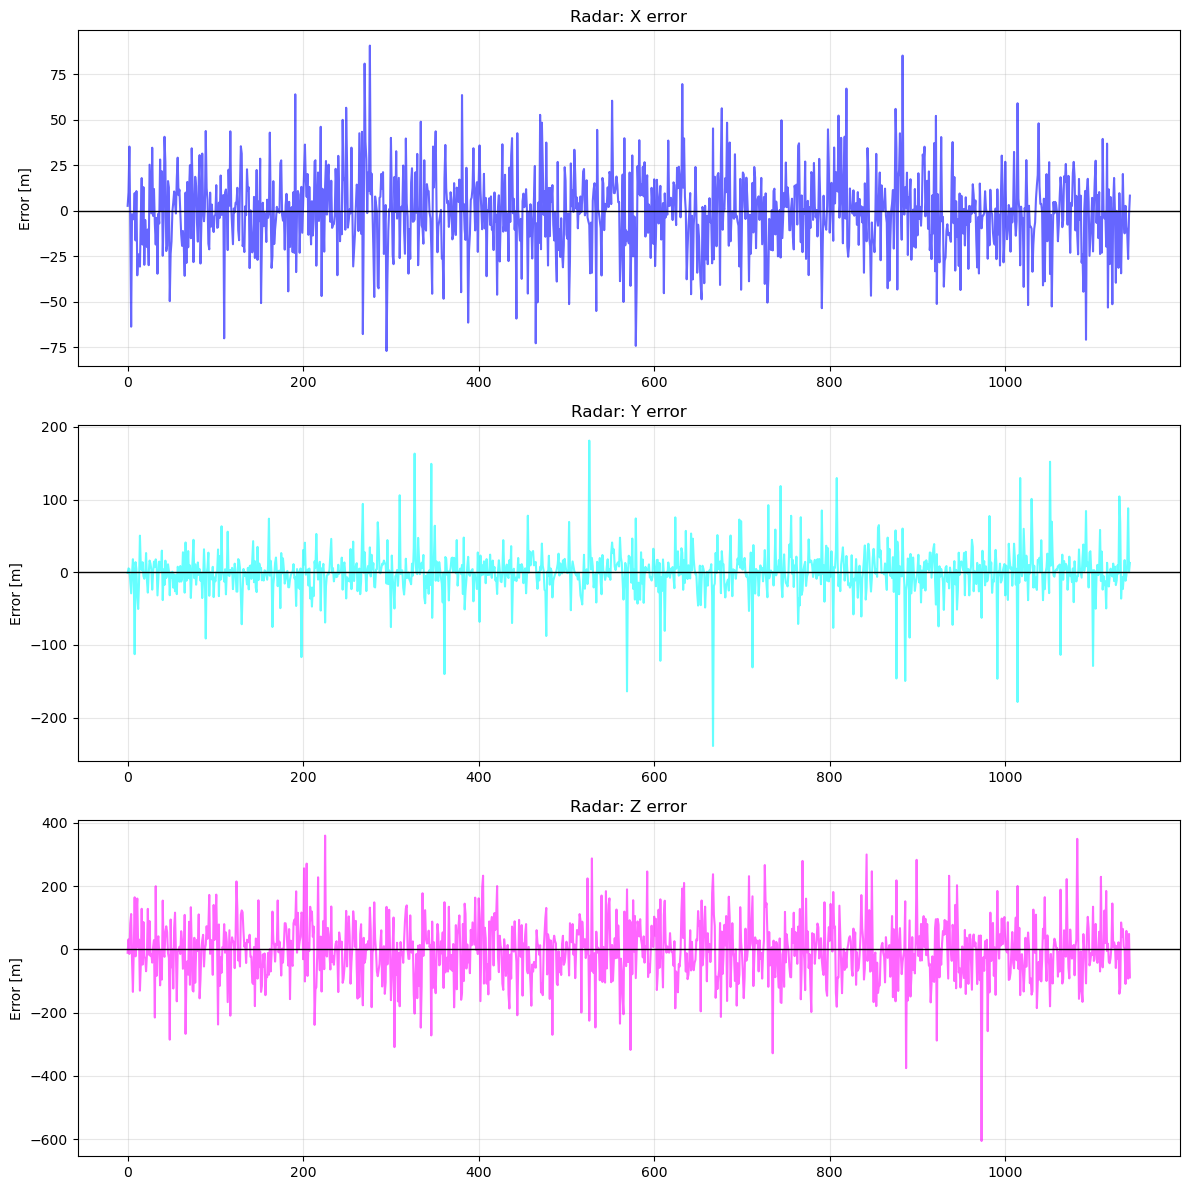

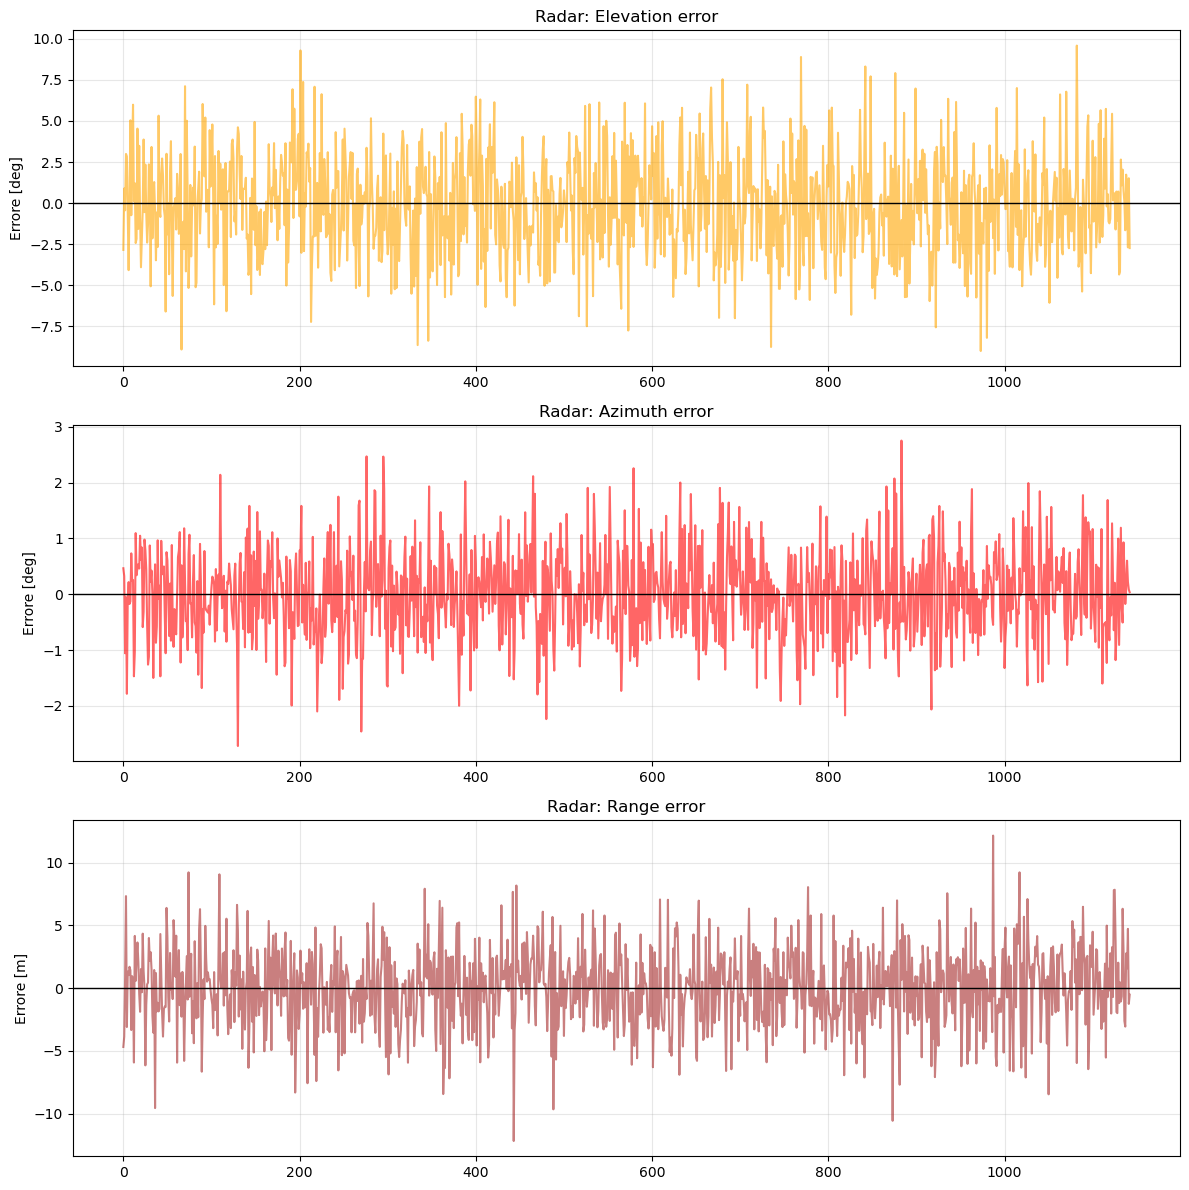

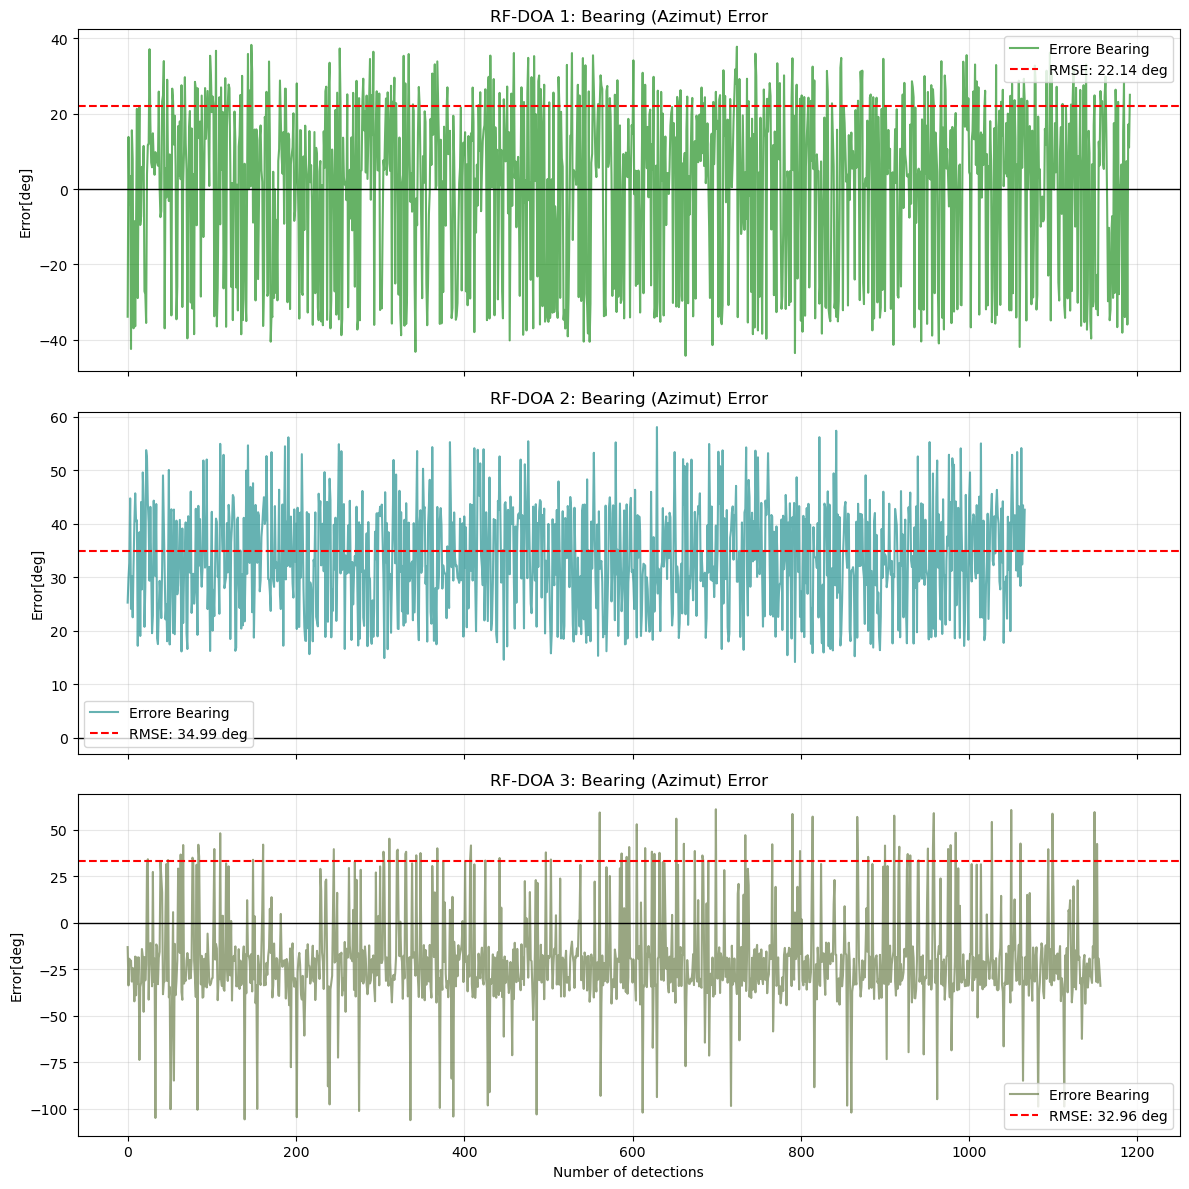

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from stonesoup.functions import cart2sphere, sphere2cart


def get_rmse(arr):
    if len(arr) == 0:
        return 0.0
    return np.sqrt(np.mean(np.array(arr) ** 2))


# Radar lists
err_r_x, err_r_y, err_r_z = [], [], []
err_r_el, err_r_az, err_r_range = [], [], []

# RF-DOA error storage (using a dictionary for the 3 sensors)
rfdoa_error_data = {
    "RF-DOA 1": {"errors": [], "pos": np.array([1000, 4000]), "dets": rfdoa1_true},
    "RF-DOA 2": {"errors": [], "pos": np.array([-3300, 1300]), "dets": rfdoa2_true},
    "RF-DOA 3": {"errors": [], "pos": np.array([4000, -2000]), "dets": rfdoa3_true},
}

# Sensors position
pos_radar = np.array([0, 0, 0])

# Radar Errors
for det in radar_true:
    # GT
    gt_state = det.groundtruth_path[det.timestamp]
    gt_pos = gt_state.state_vector[[0, 2, 4], 0]  # [x, y, z]

    # --- Cartesian metrics ---
    # spherical to cartesian radar
    el_d = float(det.state_vector[0])
    az_d = float(det.state_vector[1])
    r_d = float(det.state_vector[2])

    x_d, y_d, z_d = sphere2cart(r_d, az_d, el_d)

    # XYZ error
    err_r_x.append(x_d - gt_pos[0])
    err_r_y.append(y_d - gt_pos[1])
    err_r_z.append(z_d - gt_pos[2])

    # --- Spherical metrics ---
    # cartesian GT to spherical
    gt_r, gt_az, gt_el = cart2sphere(gt_pos[0], gt_pos[1], gt_pos[2])

    err_r_el.append(np.degrees(el_d - gt_el))
    err_r_az.append(np.degrees((az_d - gt_az + np.pi) % (2 * np.pi) - np.pi))
    err_r_range.append(r_d - gt_r)

# RF-DOA Errors for all 3 sensors
for name, data in rfdoa_error_data.items():
    sensor_pos = data["pos"]
    for det in data["dets"]:
        gt_state = det.groundtruth_path[det.timestamp]
        gt_pos_xy = gt_state.state_vector[[0, 2], 0]

        bearing_d = float(det.state_vector[0])

        # GT bearing
        v_rel = gt_pos_xy - sensor_pos
        bearing_gt = np.arctan2(v_rel[1], v_rel[0])

        err_ang = (bearing_d - bearing_gt + np.pi) % (2 * np.pi) - np.pi
        data["errors"].append(np.degrees(err_ang))


rmse_3d_radar = np.sqrt(
    np.mean(np.array(err_r_x) ** 2 + np.array(err_r_y) ** 2 + np.array(err_r_z) ** 2)
)

print("=" * 60)
print(f"{'REPORT: ERRORS':^60}")
print("=" * 60)

print(f"RADAR - 3D RMSE: {rmse_3d_radar:.3f} m")

print(
    f"RADAR - Max error -> "
    f"X: {np.max(np.abs(err_r_x)):.2f}m, "
    f"Y: {np.max(np.abs(err_r_y)):.2f}m, "
    f"Z: {np.max(np.abs(err_r_z)):.2f}m"
)

print("-" * 60)

print(
    f"RADAR - Max Error -> "
    f"Elevation: {np.max(np.abs(err_r_el)):.3f} deg, "
    f"Azimuth: {np.max(np.abs(err_r_az)):.3f} deg, "
    f"Range: {np.max(np.abs(err_r_range)):.2f}m"
)

print(
    f"RADAR - RMSE -> "
    f"Elevation: {get_rmse(err_r_el):.3f} deg "
    f"Azimuth: {get_rmse(err_r_az):.3f} deg "
    f"Range: {get_rmse(err_r_range):.3f}m"
)

print("+" * 60)

# Print RF-DOA errors matching original style
for name, data in rfdoa_error_data.items():
    errs = data["errors"]
    if not errs:
        continue

    print(f"{name} - RMSE Bearing: {get_rmse(errs):.3f} deg")
    print(
        f"{name} - Bearing error -> "
        f"Max: {np.max(np.abs(errs)):.3f} deg, "
        f"Min: {np.min(np.abs(errs)):.3f} deg"
    )
    print("-" * 30)

print("=" * 60)


# --- 3. PLOTS ---

# --- FIGURE 1: (X, Y, Z) ---
fig1, axs1 = plt.subplots(3, 1, figsize=(12, 12))

coords = [
    ("X", err_r_x, "blue"),
    ("Y", err_r_y, "cyan"),
    ("Z", err_r_z, "magenta"),
]

for i, (name, data, color) in enumerate(coords):
    axs1[i].plot(data, color=color, alpha=0.6)
    axs1[i].axhline(0, color="black", lw=1)
    axs1[i].set_title(f"Radar: {name} error")
    axs1[i].set_ylabel("Error [m]")
    axs1[i].grid(True, alpha=0.3)

plt.tight_layout()

# --- FIGURE 2: RADAR Error (El, Az, Range) ---
fig2, axs2 = plt.subplots(3, 1, figsize=(12, 12))

polars = [
    ("Elevation", err_r_el, "orange", "deg"),
    ("Azimuth", err_r_az, "red", "deg"),
    ("Range", err_r_range, "brown", "m"),
]

for i, (name, data, color, unit) in enumerate(polars):
    axs2[i].plot(data, color=color, alpha=0.6)
    axs2[i].axhline(0, color="black", lw=1)
    axs2[i].set_title(f"Radar: {name} error")
    axs2[i].set_ylabel(f"Errore [{unit}]")
    axs2[i].grid(True, alpha=0.3)

plt.tight_layout()

# --- FIGURE 3: RF-DOA BEARING (3 Subplots) ---
fig3, axs3 = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors_rf = ["green", "teal", "darkolivegreen"]

for i, (name, data) in enumerate(rfdoa_error_data.items()):
    errs = data["errors"]
    if not errs:
        continue

    axs3[i].plot(errs, color=colors_rf[i], alpha=0.6, label="Errore Bearing")
    rmse = get_rmse(errs)
    axs3[i].axhline(rmse, color="red", linestyle="--", label=f"RMSE: {rmse:.2f} deg")
    axs3[i].axhline(0, color="black", lw=1)

    axs3[i].set_title(f"{name}: Bearing (Azimut) Error")
    axs3[i].set_ylabel("Error[deg]")
    axs3[i].legend()
    axs3[i].grid(True, alpha=0.3)

plt.xlabel("Number of detections")
plt.tight_layout()

plt.show()


---
## Radar Tracker

Questo percorso di tracking utilizza **esclusivamente le detection del radar** (CartesianToElevationBearingRange).
Le detection RF-DOA non entrano in questo tracker.


In [20]:
## Setup the radar tracking algorithm

ukp_trans_mod =  CombinedGaussianTransitionModel([
    ConstantVelocity(20),
    ConstantVelocity(20),
    ConstantVelocity(20),
])


# Istance of ExtendedKalmanPredictor class

predictor = UnscentedKalmanPredictor(ukp_trans_mod)

# Istance of ExtendedKalmanUpdater

updater = UnscentedKalmanUpdater(measurement_model = None)


In [21]:
## Data Association

# Create a PDAHypothesiser istance.

Pd = 0.95  # 95% chance to measure any given target at any given timestep.

hypothesiser = PDAHypothesiser(predictor = predictor,
                               updater = updater,
                               # clutter_spatial_density = 1e-9,
                               prob_detect = Pd)

# JPDA Associator istance

data_associator = JPDA(hypothesiser = hypothesiser)


In [22]:
## Delete tracks if no measurements have fallen within the JPDA gating region in 3 time steps.


# Deleter istance

deleter = UpdateTimeStepsDeleter(time_steps_since_update = 10)


In [23]:
## Initiator definition

min_detections = 10 # number of detections required to begin a track

initiator_prior_state = GaussianState(
    state_vector = np.array([[0], [0], [0], [0], [0], [0]]), covar = np.diag([1000, 50, 1000, 50, 500, 20])**2
)

# The measurement model of the sensor is used because the overall data stream is composed by
# detections of this type.

initiator_meas_model = CartesianToElevationBearingRange(
    ndim_state = 10,
    mapping = np.array([0, 2, 4]),
    noise_covar = noise_covar
)

# Create the Initiator object for tracker

initiator = MultiMeasurementInitiator(
    prior_state = initiator_prior_state,
    measurement_model = initiator_meas_model,
    deleter = deleter,
    data_associator = NearestNeighbour(hypothesiser),
    updater = updater,
    min_points = min_detections,
    updates_only = True,
    skip_non_reversible = True
)


In [24]:
## JPDA Multi-target Tracker - Radar only
# NOTE: radar_tracker_input contains ONLY radar detections (no RF-DOA)

JPDA_radar_tracker = MultiTargetMixtureTracker(
    initiator = initiator,
    deleter = deleter,
    detector = radar_tracker_input,   # SOLO detection radar
    data_associator = data_associator,
    updater = updater
)


Tracce radar prodotte: 12


/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_52975/1959768720.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_radar = plt.cm.get_cmap('tab10', len(radar_tracks))
/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_52975/1959768720.py:37: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  plotter2d.ax.plot(700, 2300, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (700, 2300)', zorder=10)
/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_52975/1959768720.py:38: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  plotter2d.ax.plot(-2300,

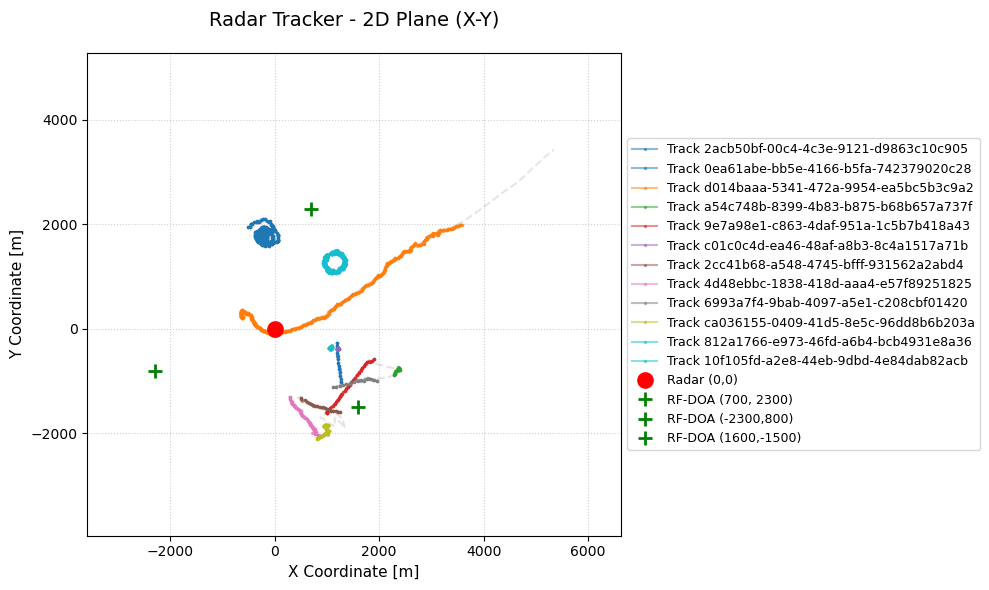

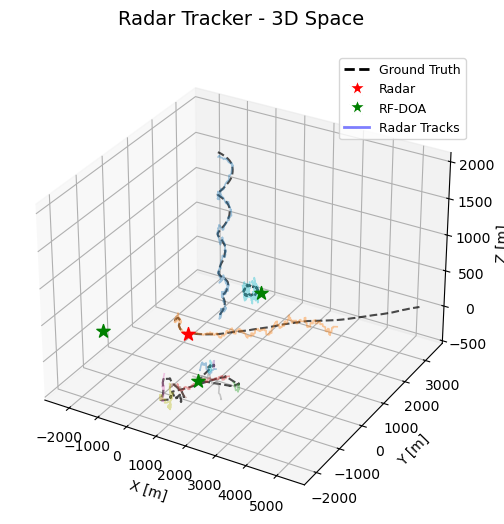

In [25]:
### Radar Tracking Loop & Advanced Plotting

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from stonesoup.plotter import Plotter, Dimension
import numpy as np

# 1. Recupero dei dati (assicurati che JPDA_radar_tracker sia appena stato inizializzato)
radar_tracks = set()
for time, ctracks in JPDA_radar_tracker:
    radar_tracks.update(ctracks)

print(f'Tracce radar prodotte: {len(radar_tracks)}')

# Definizione di una palette colori per le tracce
colors_radar = plt.cm.get_cmap('tab10', len(radar_tracks))

# -----------------------------------------------------------------
# 2D Plot - X-Y plane (Radar Tracker)
# -----------------------------------------------------------------
plotter2d = Plotter(dimension=Dimension.TWO)

# Plot Ground Truth (nero tratteggiato, sotto le tracce)
plotter2d.plot_ground_truths(truths, [0, 2], color='black', linestyle='--', alpha=0.1)

# Plot manuale delle Tracce con trasparenza
for i, track in enumerate(radar_tracks):
    # Estraiamo le coordinate x (0) e y (2)
    tx = [state.state_vector[0, 0] for state in track.states]
    ty = [state.state_vector[2, 0] for state in track.states]
    
    plotter2d.ax.plot(tx, ty, marker='.', markersize=3, linewidth=1.5, 
                      color=colors_radar(i), alpha=0.5, label=f'Track {track.id}')

# Plot dei Sensori (Marker grandi e visibili)
plotter2d.ax.plot(0, 0, 'ro', markersize=10, markeredgewidth=2, label='Radar (0,0)', zorder=10)
plotter2d.ax.plot(700, 2300, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (700, 2300)', zorder=10)
plotter2d.ax.plot(-2300, -800, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (-2300,800)', zorder=10)
plotter2d.ax.plot(1600, -1500, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (1600,-1500)', zorder=10)

# Configurazione Legenda e Label 2D
plotter2d.ax.set_title('Radar Tracker - 2D Plane (X-Y)', fontsize=14, pad=20)
plotter2d.ax.set_xlabel('X Coordinate [m]', fontsize=11)
plotter2d.ax.set_ylabel('Y Coordinate [m]', fontsize=11)
plotter2d.ax.grid(True, linestyle=':', alpha=0.6)

# Creazione legenda personalizzata esterna per non coprire il grafico
plotter2d.ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, ncol=1)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 3D Plot - X-Y-Z (Radar Tracker)
# -----------------------------------------------------------------
plotter3d = Plotter(dimension=Dimension.THREE)

# Plot Ground Truth 3D
plotter3d.plot_ground_truths(truths, [0, 2, 4], color='black', linestyle='--', alpha=0.7)

# Plot manuale delle Tracce 3D con trasparenza
for i, track in enumerate(radar_tracks):
    tx = [state.state_vector[0, 0] for state in track.states]
    ty = [state.state_vector[2, 0] for state in track.states]
    tz = [state.state_vector[4, 0] for state in track.states]
    
    plotter3d.ax.plot(tx, ty, tz, linewidth=1.2, color=colors_radar(i), alpha=0.4)

# Plot Sensori 3D (Marker a stella)
plotter3d.ax.scatter(0, 0, 0, color='red', s=100, marker='*', label='Radar Platform', zorder=10)
plotter3d.ax.scatter(700, 2300, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)
plotter3d.ax.scatter(-2300, -800, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)
plotter3d.ax.scatter(1600, -1500, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)

# Configurazione 3D
plotter3d.ax.set_title('Radar Tracker - 3D Space', fontsize=14, pad=20)
plotter3d.ax.set_xlabel('X [m]')
plotter3d.ax.set_ylabel('Y [m]')
plotter3d.ax.set_zlabel('Z [m]')

# Legenda manuale per il 3D (per evitare che diventi troppo grande)
custom_lines = [Line2D([0], [0], color='black', lw=2, linestyle='--'),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='green', markersize=12),
                Line2D([0], [0], color='blue', lw=2, alpha=0.5)]

plotter3d.ax.legend(custom_lines, ['Ground Truth', 'Radar', 'RF-DOA', 'Radar Tracks'], 
                    loc='upper right', fontsize=9)

plt.show()


---
## RF-DOA Tracker - Two-Stage Pipeline

Questo percorso di tracking utilizza **esclusivamente le detection triangolate dai 3 sensori RF-DOA**.
Le detection radar non entrano in questo tracker.

### Architettura della pipeline

```
Sensori (x3)                  Stage 1                         Stage 2
RF-DOA 1 -> bearing1(t) --+
RF-DOA 2 -> bearing2(t) --+--> TRIANGULATION ENGINE --> CartesianToBearingRange dets
RF-DOA 3 -> bearing3(t) --+    zip-sync + LS intersection    (bearing, range) da origine
                               -> (x,y) per ogni target
                                                           -> JPDA Tracker (UKF)
                                                           -> TRACCE STIMATE
```


## Stage 1 - Triangulation Engine


In [26]:
def compute_triangulation_covariance(sensor_positions, bearings_rad, xy_est, sigma_bearing_rad):
    """
    Propaga l'incertezza di bearing dei sensori alla covarianza della detection
    triangolata, usando la propagazione lineare dell'errore al primo ordine.
    Supporta adattivamente 2 o 3 sensori attivi (n >= 2).
    """
    n = len(bearings_rad)
    A = np.array([[np.sin(b), -np.cos(b)] for b in bearings_rad])
    A_pinv = np.linalg.pinv(A)

    d = np.array([
        np.cos(b) * sx + np.sin(b) * sy
        for (sx, sy), b in zip(sensor_positions, bearings_rad)
    ])
    D = np.diag(d)
    J_pos = A_pinv @ D

    Sigma_b  = (sigma_bearing_rad ** 2) * np.eye(n)
    Sigma_xy = J_pos @ Sigma_b @ J_pos.T

    x, y = float(xy_est[0]), float(xy_est[1])
    r    = math.sqrt(x ** 2 + y ** 2)
    if r < 1.0:
        return np.diag([np.deg2rad(15.0) ** 2, 2000.0 ** 2])

    H = np.array([
        [-y / r ** 2,  x / r ** 2],
        [ x / r,       y / r     ],
    ])
    Sigma_det = H @ Sigma_xy @ H.T

    # --- Regolarizzazione e Clamping robusto della covarianza ---
    var_b = float(Sigma_det[0, 0])
    var_r = float(Sigma_det[1, 1])

    # Clamp varianza bearing tra (1.0 deg)^2 e (30.0 deg)^2
    var_b_clamped = np.clip(var_b, np.deg2rad(1.0)**2, np.deg2rad(30.0)**2)
    # Clamp varianza range tra (30.0 m)^2 e (2000.0 m)^2
    var_r_clamped = np.clip(var_r, 30.0**2, 2000.0**2)

    # Estrazione coefficiente di correlazione e clamping a [-0.95, 0.95] per evitare singolarita
    corr = 0.0
    if var_b > 0 and var_r > 0:
        corr = Sigma_det[0, 1] / np.sqrt(var_b * var_r)
    corr_clamped = np.clip(corr, -0.95, 0.95)

    # Ricostruzione covarianza robusta semi-definita positiva (SPD)
    cov_res = np.zeros((2, 2))
    cov_res[0, 0] = var_b_clamped
    cov_res[1, 1] = var_r_clamped
    cov_res[0, 1] = corr_clamped * np.sqrt(var_b_clamped * var_r_clamped)
    cov_res[1, 0] = cov_res[0, 1]

    return cov_res


def triangulation_engine(det_sims):
    """
    Stage 1: Triangolazione Adattiva Multi-Sensore (2 o 3 sensori attivi).

    Per ogni step temporale:
    1. Riceve le detection dai sensori e identifica quelli attivi (con >= 1 detection).
    2. Se ci sono meno di 2 sensori attivi, skip (impossibile triangolare).
    3. Per ogni coppia di sensori attivi, calcola l'intersezione di tutte le combinazioni di bearing.
    4. Per ogni punto candidato, conta quanti sensori hanno una retta di bearing passante vicino al punto.
    5. Calcola la covarianza adattiva basata solo sui sensori che hanno effettivamente contribuito.
    6. Deduplica spazialmente i punti candidati.
    7. Genera le Detection[CartesianToBearingRange] con covarianza robusta e geometry-dependent.
    """
    sigma_bearing_rad = np.deg2rad(rfdoa_azi_nois_std_dev)
    RAY_DIST_THRESHOLD = 400.0  # massima distanza perpendicolare per considerare un sensore contribuente [m]

    for step_data in zip(*det_sims):
        timestamp = step_data[0][0]

        # Raccoglie bearing per ciascun sensore (radianti)
        s_rays = []
        for i, (ts, dets) in enumerate(step_data):
            s_rays.append([float(d.state_vector[0]) for d in dets])

        active_sensors = [i for i, r in enumerate(s_rays) if len(r) > 0]
        if len(active_sensors) < 2:
            yield timestamp, set()
            continue

        candidates = []
        # Calcola le intersezioni tra tutte le coppie di sensori attivi
        for idx1, idx2 in combinations(active_sensors, 2):
            pos1 = SENSOR_POSITIONS[idx1]
            pos2 = SENSOR_POSITIONS[idx2]

            for b1 in s_rays[idx1]:
                for b2 in s_rays[idx2]:
                    # Sistema 2x2 per intersezione esatta
                    A = np.array([
                        [np.sin(b1), -np.cos(b1)],
                        [np.sin(b2), -np.cos(b2)]
                    ])
                    det_val = np.sin(b1 - b2)
                    if abs(det_val) < 1e-3:  # rette quasi parallele
                        continue

                    b_vec = np.array([
                        np.sin(b1)*pos1[0] - np.cos(b1)*pos1[1],
                        np.sin(b2)*pos2[0] - np.cos(b2)*pos2[1]
                    ])
                    pt = np.linalg.solve(A, b_vec)

                    if np.linalg.norm(pt) > 25000:
                        continue

                    # Verifica quanti sensori supportano effettivamente questa intersezione
                    contributing_sensors = []
                    bearings_used = []
                    positions_used = []

                    for s_idx in range(len(SENSOR_POSITIONS)):
                        if len(s_rays[s_idx]) == 0:
                            continue
                        pos_s = SENSOR_POSITIONS[s_idx]

                        # Trova il bearing piu vicino al punto candidato
                        best_b = None
                        best_dist = 1e9
                        for b_rad in s_rays[s_idx]:
                            # check direzione frontale
                            t = np.cos(b_rad)*(pt[0] - pos_s[0]) + np.sin(b_rad)*(pt[1] - pos_s[1])
                            if t < -100:
                                continue
                            # distanza ortogonale
                            d_perp = abs(np.sin(b_rad)*(pt[0] - pos_s[0]) - np.cos(b_rad)*(pt[1] - pos_s[1]))
                            if d_perp < best_dist:
                                best_dist = d_perp
                                best_b = b_rad

                        if best_dist < RAY_DIST_THRESHOLD:
                            contributing_sensors.append(s_idx)
                            bearings_used.append(best_b)
                            positions_used.append(pos_s)

                    if len(contributing_sensors) >= 2:
                        cov = compute_triangulation_covariance(
                            positions_used, bearings_used, pt, sigma_bearing_rad
                        )
                        candidates.append({
                            "pt": pt,
                            "num_sensors": len(contributing_sensors),
                            "bearings": bearings_used,
                            "cov": cov
                        })

        # Ordina per robustezza (punti supportati da 3 sensori hanno priorita su quelli da 2)
        candidates.sort(key=lambda c: c["num_sensors"], reverse=True)

        # Deduplicazione spaziale
        deduped = []
        for c in candidates:
            if not any(
                np.linalg.norm(c["pt"] - d["pt"]) < TRIANG_DEDUP_DIST
                for d in deduped
            ):
                deduped.append(c)

        # Crea le detection finali
        out = set()
        for c in deduped:
            pt = c["pt"]
            meas_model = CartesianToBearingRange(
                ndim_state=6,
                mapping=(0, 2),
                noise_covar=c["cov"],
                translation_offset=StateVector([[0], [0]]),
            )
            b_orig = float(np.arctan2(pt[1], pt[0]))
            r_orig = float(np.linalg.norm(pt))
            out.add(Detection(
                state_vector=StateVector([[b_orig], [r_orig]]),
                timestamp=timestamp,
                measurement_model=meas_model
            ))

        yield timestamp, out


## Risultati Stage 1: Statistiche Triangolazione


In [27]:
## Risultati Stage 1: Statistiche Triangolazione

# Crea gli stream: uno per le statistiche/plot, uno per il tracker
triang_for_stats, triang_for_tracker = tee(
    triangulation_engine([rfdoa_for_triangulation_1, rfdoa_for_triangulation_2, rfdoa_for_triangulation_3]), 2
)

# Raccoglie detections triangolate per analisi
triangulated_all = {}
for ts, dets in triang_for_stats:
    triangulated_all[ts] = dets

total_triang = sum(len(d) for d in triangulated_all.values())
steps_with   = sum(1 for d in triangulated_all.values() if len(d) > 0)

print(f'Detections triangolate totali : {total_triang}')
print(f'Step con >= 1 triangolazione  : {steps_with}/{num_steps}')
print(f'Media per step                : {total_triang/num_steps:.2f}')


Detections triangolate totali : 2158
Step con >= 1 triangolazione  : 1161/300
Media per step                : 7.19


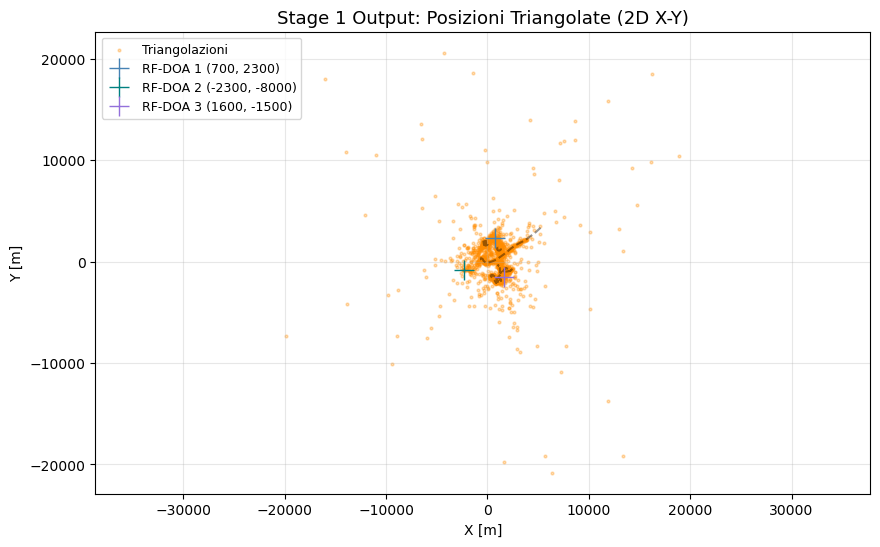


Statistiche posizioni triangolate:
  X: mean=679m  std=1946m  range=[-19846, 18922]m
  Y: mean=548m  std=2330m  range=[-20818, 20617]m


In [28]:
## Visualizzazione Detection Triangolate vs Ground Truth

all_tri_xy = np.array([
    [float(d.state_vector[1]) * np.cos(float(d.state_vector[0])),
     float(d.state_vector[1]) * np.sin(float(d.state_vector[0]))]
    for dets in triangulated_all.values()
    for d in dets
]) if total_triang > 0 else np.zeros((0, 2))

plotter_tri = Plotter(dimension=Dimension.TWO)
plotter_tri.plot_ground_truths(truths, [0, 2], color='black', linestyle='--', alpha=0.4,
                                label='Ground truth')

if len(all_tri_xy) > 0:
    plotter_tri.ax.scatter(all_tri_xy[:, 0], all_tri_xy[:, 1],
                           s=4, alpha=0.3, color='darkorange', label='Triangolazioni')

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter_tri.ax.plot(x, y, '+', color=color, markersize=14, zorder=10, label=label)

plotter_tri.ax.set_title('Stage 1 Output: Posizioni Triangolate (2D X-Y)', fontsize=13)
plotter_tri.ax.set_xlabel('X [m]'); plotter_tri.ax.set_ylabel('Y [m]')
plotter_tri.ax.legend(fontsize=9, loc='upper left')
plotter_tri.ax.grid(True, alpha=0.3)
plt.show()

print(f'\nStatistiche posizioni triangolate:')
if len(all_tri_xy) > 0:
    print(f'  X: mean={all_tri_xy[:,0].mean():.0f}m  std={all_tri_xy[:,0].std():.0f}m  '
          f'range=[{all_tri_xy[:,0].min():.0f}, {all_tri_xy[:,0].max():.0f}]m')
    print(f'  Y: mean={all_tri_xy[:,1].mean():.0f}m  std={all_tri_xy[:,1].std():.0f}m  '
          f'range=[{all_tri_xy[:,1].min():.0f}, {all_tri_xy[:,1].max():.0f}]m')


## Stage 2 - RF-DOA JPDA Tracker


In [29]:
## UKF Predictor e Updater - RF-DOA Tracker

ukf_trans_mod_rfdoa = CombinedGaussianTransitionModel([
    ConstantVelocity(100),
    ConstantVelocity(100),
    ConstantVelocity(100),
])

predictor_rfdoa = UnscentedKalmanPredictor(ukf_trans_mod_rfdoa)
updater_rfdoa   = UnscentedKalmanUpdater(measurement_model=None)


In [30]:
## JPDA Data Associator - RF-DOA Tracker

Pd_rfdoa = 0.95

hypothesiser_rfdoa = PDAHypothesiser(
    predictor               = predictor_rfdoa,
    updater                 = updater_rfdoa,
    #clutter_spatial_density = 1e-9,
    prob_detect             = Pd_rfdoa,
)
data_associator_rfdoa = JPDA(hypothesiser=hypothesiser_rfdoa)


In [31]:
## Deleter - RF-DOA Tracker

deleter_rfdoa = UpdateTimeStepsDeleter(time_steps_since_update=20)


In [32]:
## MultiMeasurementInitiator - RF-DOA Tracker
#
# Le detection del triangulation_engine portano gia il proprio measurement_model
# (CartesianToBearingRange con covarianza geometry-dependent -> ReversibleModel).
# origin_meas_model e usato come fallback per detection senza modello proprio.

origin_meas_model_rfdoa = CartesianToBearingRange(
    ndim_state         = 6,
    mapping            = (0, 2),
    noise_covar        = np.diag([np.deg2rad(5.0) ** 2, 500.0 ** 2]),
    translation_offset = StateVector([[0], [0]]),
)

# Stato iniziale per l'iniziatore delle tracce.
# La posizione viene aggiornata dalle prime 'min_points' detection via inverse_function();
# la covarianza ampia in posizione copre l'intera area di ricerca.

prior_state_rfdoa = GaussianState(
    state_vector = StateVector([[0], [0], [0], [0], [0], [0]]),
    covar        = np.diag([1000, 50, 1000, 50, 200, 20])**2,
    timestamp    = start_time,
)

initiator_rfdoa = MultiMeasurementInitiator(
    prior_state         = prior_state_rfdoa,
    measurement_model   = origin_meas_model_rfdoa,   # fallback
    deleter             = deleter_rfdoa,
    data_associator     = NearestNeighbour(hypothesiser_rfdoa),
    updater             = updater_rfdoa,
    min_points          = 150,                   # step consecutivi per confermare traccia
    updates_only        = False,
    skip_non_reversible = True,
)


In [33]:
## MultiTargetMixtureTracker - RF-DOA (JPDA)
# NOTE: triang_for_tracker contiene SOLO detection triangolate dai sensori RF-DOA

JPDA_rfdoa_tracker = MultiTargetMixtureTracker(
    initiator       = initiator_rfdoa,
    deleter         = deleter_rfdoa,
    detector        = triang_for_tracker,   # stream Stage 1 - solo RF-DOA
    data_associator = data_associator_rfdoa,
    updater         = updater_rfdoa,
)


In [34]:
## RF-DOA Tracking Loop

rfdoa_tracks_all = set()
for time, ctracks in JPDA_rfdoa_tracker:
    rfdoa_tracks_all.update(ctracks)

MIN_TRACK_LEN_RFDOA = max(50, int(num_steps * 0.05))
rfdoa_long_tracks = {t for t in rfdoa_tracks_all if len(t.states) >= MIN_TRACK_LEN_RFDOA}

print(f'Tracce RF-DOA totali prodotte  : {len(rfdoa_tracks_all)}')
print(f'Tracce lunghe (>={MIN_TRACK_LEN_RFDOA} stati)  : {len(rfdoa_long_tracks)}')
print(f'Ground truth paths             : {len(truths)}')


/opt/anaconda3/envs/cdfusion/lib/python3.10/site-packages/stonesoup/functions/__init__.py:225: UserWarning: LinAlgError('Matrix is not positive definite')
  warnings.warn(repr(e))


Tracce RF-DOA totali prodotte  : 5
Tracce lunghe (>=50 stati)  : 5
Ground truth paths             : 4


/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_52975/1717725473.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_rfdoa = plt.cm.get_cmap('tab10', max(len(rfdoa_long_tracks), 1))


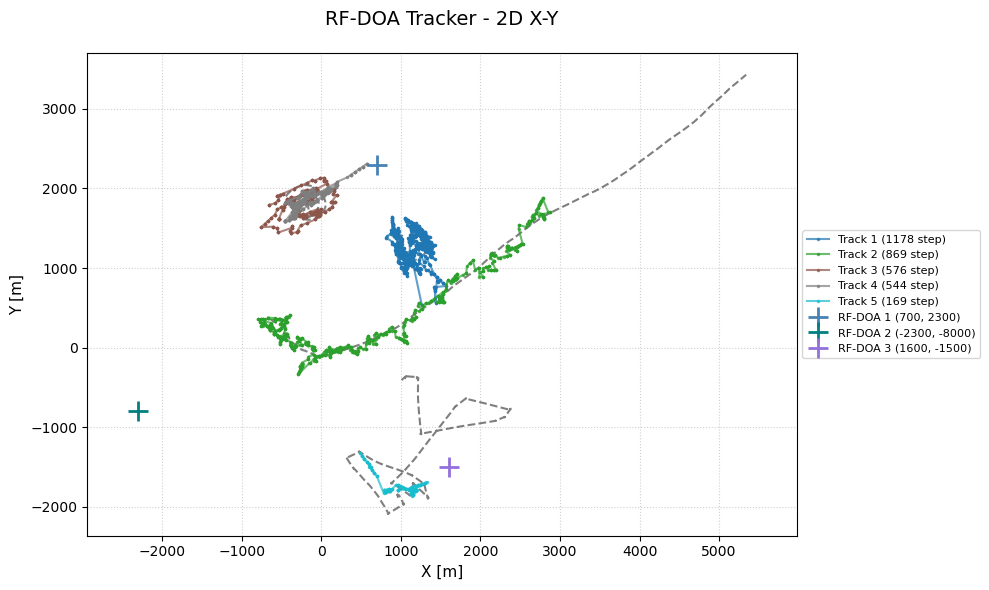

In [35]:
### RF-DOA Tracker - Plot 2D (X-Y)

colors_rfdoa = plt.cm.get_cmap('tab10', max(len(rfdoa_long_tracks), 1))

plotter2d_rfdoa = Plotter(dimension=Dimension.TWO)
plotter2d_rfdoa.plot_ground_truths(truths, [0, 2], color='black', linestyle='--',
                              alpha=0.5, label='Ground truth')

for i, track in enumerate(sorted(rfdoa_long_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    plotter2d_rfdoa.ax.plot(tx, ty, marker='.', markersize=3, linewidth=1.5,
                      color=colors_rfdoa(i), alpha=0.7, label=f'Track {i+1} ({len(track.states)} step)')

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter2d_rfdoa.ax.plot(x, y, '+', color=color, markersize=14, markeredgewidth=2,
                      zorder=10, label=label)

plotter2d_rfdoa.ax.set_title('RF-DOA Tracker - 2D X-Y', fontsize=14, pad=20)
plotter2d_rfdoa.ax.set_xlabel('X [m]', fontsize=11); plotter2d_rfdoa.ax.set_ylabel('Y [m]', fontsize=11)
plotter2d_rfdoa.ax.grid(True, linestyle=':', alpha=0.6)
plotter2d_rfdoa.ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); plt.show()


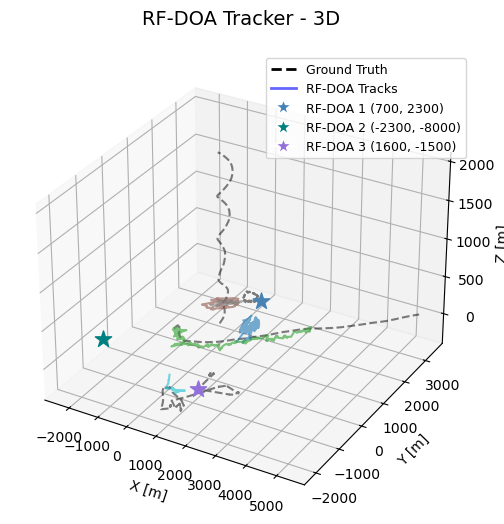

In [36]:
### RF-DOA Tracker - Plot 3D

plotter3d_rfdoa = Plotter(dimension=Dimension.THREE)
plotter3d_rfdoa.plot_ground_truths(truths, [0, 2, 4], color='black', linestyle='--', alpha=0.5)

for i, track in enumerate(sorted(rfdoa_long_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    tz = [s.state_vector[4, 0] for s in track.states]
    plotter3d_rfdoa.ax.plot(tx, ty, tz, linewidth=1.5, color=colors_rfdoa(i), alpha=0.6)

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter3d_rfdoa.ax.scatter(x, y, 0, color=color, s=150, marker='*', zorder=10, label=label)

custom_lines_rfdoa = [
    Line2D([0],[0], color='black', lw=2, linestyle='--'),
    Line2D([0],[0], color='blue',  lw=2, alpha=0.6),
    *[Line2D([0],[0], marker='*', color='w', markerfacecolor=c, markersize=12)
      for c in SENSOR_COLORS],
]
plotter3d_rfdoa.ax.legend(custom_lines_rfdoa,
                    ['Ground Truth', 'RF-DOA Tracks'] + SENSOR_LABELS,
                    loc='upper right', fontsize=9)
plotter3d_rfdoa.ax.set_title('RF-DOA Tracker - 3D', fontsize=14, pad=20)
plotter3d_rfdoa.ax.set_xlabel('X [m]'); plotter3d_rfdoa.ax.set_ylabel('Y [m]'); plotter3d_rfdoa.ax.set_zlabel('Z [m]')
plt.show()


In [37]:
## Track Quality Metrics - RF-DOA Tracker

if rfdoa_long_tracks:
    lengths = [len(t.states) for t in rfdoa_long_tracks]
    print('='*65)
    print(f"{'TRACK QUALITY SUMMARY - RF-DOA Two-Stage Pipeline':^65}")
    print('='*65)
    print(f'Ground truth targets          : {len(truths)}')
    print(f'Tracce totali prodotte        : {len(rfdoa_tracks_all)}')
    print(f'Tracce lunghe (post-filtro)   : {len(rfdoa_long_tracks)}')
    print(f'Lunghezza - media             : {np.mean(lengths):.1f} step')
    print(f'Lunghezza - max               : {np.max(lengths)} step  ({np.max(lengths)/num_steps*100:.0f}%)')
    print(f'Lunghezza - min               : {np.min(lengths)} step')
    print('='*65)
    print()
    print('NOTA sulla coordinata Z (altitudine):')
    print('I sensori RF-DOA misurano solo bearing nel piano XY.')
    print('La quota Z e stimata dal prior e dal modello di transizione UKF.')
    print('Per tracking 3D preciso servono sensori con misura di elevation.')
else:
    print('Nessuna traccia lunga. Prova a ridurre MIN_TRACK_LEN_RFDOA o min_points.')


        TRACK QUALITY SUMMARY - RF-DOA Two-Stage Pipeline        
Ground truth targets          : 4
Tracce totali prodotte        : 5
Tracce lunghe (post-filtro)   : 5
Lunghezza - media             : 667.2 step
Lunghezza - max               : 1178 step  (393%)
Lunghezza - min               : 169 step

NOTA sulla coordinata Z (altitudine):
I sensori RF-DOA misurano solo bearing nel piano XY.
La quota Z e stimata dal prior e dal modello di transizione UKF.
Per tracking 3D preciso servono sensori con misura di elevation.
